In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import logging
from sklearn.preprocessing import StandardScaler

import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import joblib
from datetime import datetime
from statsmodels.tsa.stattools import adfuller

import logging

sns.set(style="whitegrid")

In [6]:
with zipfile.ZipFile(r"C:\Users\saket\Downloads\rossmann-store-sales.zip", 'r') as zip_ref:
    zip_ref.extractall('data')

In [7]:
import os
os.listdir('data')

['sample_submission.csv', 'store.csv', 'test.csv', 'train.csv']

In [8]:
df = pd.read_csv('data/train.csv')

C:\Users\saket\AppData\Local\Temp\ipykernel_14852\1827706672.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/train.csv')


In [9]:
df.head()
df.info()
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00
mean,558.43,4.00,5773.82,633.15,0.83,0.38,0.18
std,321.91,2.00,3849.93,464.41,0.38,0.49,0.38
min,1.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,280.00,2.00,3727.00,405.00,1.00,0.00,0.00
50%,558.00,4.00,5744.00,609.00,1.00,0.00,0.00
75%,838.00,6.00,7856.00,837.00,1.00,1.00,0.00
max,1115.00,7.00,41551.00,7388.00,1.00,1.00,1.00


In [10]:
train = pd.read_csv(r"C:\Users\saket\Downloads\rossmann-store-sales\train.csv", low_memory=False)
test = pd.read_csv(r"C:\Users\saket\Downloads\rossmann-store-sales\test.csv", low_memory=False)

In [11]:
# Promo distribution
train['Promo'].value_counts(normalize=True)
test['Promo'].value_counts(normalize=True)

Promo
0   0.60
1   0.40
Name: proportion, dtype: float64

       Train  Test
Promo             
0       0.62  0.60
1       0.38  0.40


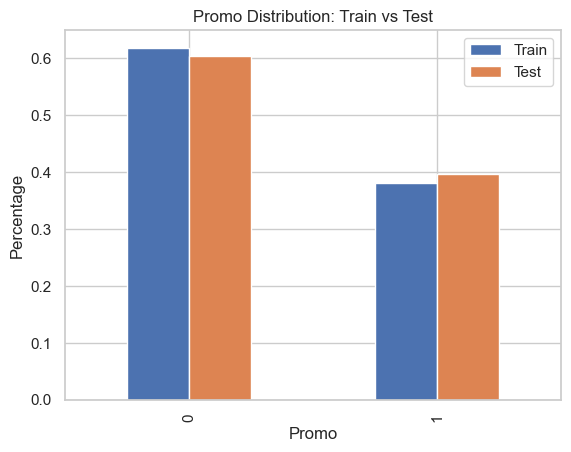

In [12]:
train_promo = train['Promo'].value_counts(normalize=True)
test_promo = test['Promo'].value_counts(normalize=True)
# comparision
comparison = pd.DataFrame({
    'Train': train_promo,
    'Test': test_promo
})

print(comparison)

# visulation between train and test 

comparison.plot(kind='bar')
plt.title("Promo Distribution: Train vs Test")
plt.ylabel("Percentage")
plt.show()

### ***Sales behaiviour***

In [13]:
# Date convert
train['Date'] = pd.to_datetime(train['Date'])

# Holiday indicator
train['IsHoliday'] = train['StateHoliday'].apply(lambda x: 0 if x == '0' else 1)

train = train.sort_values(['Store', 'Date'])

# Previous day holiday
train['BeforeHoliday'] = train.groupby('Store')['IsHoliday'].shift(-1)

# Next day holiday
train['AfterHoliday'] = train.groupby('Store')['IsHoliday'].shift(1)

In [14]:
before_sales = train[train['BeforeHoliday'] == 1]['Sales'].mean()
holiday_sales = train[train['IsHoliday'] == 1]['Sales'].mean()
after_sales = train[train['AfterHoliday'] == 1]['Sales'].mean()

print("Before Holiday Sales:", before_sales)
print("Holiday Sales:", holiday_sales)
print("After Holiday Sales:", after_sales)

Before Holiday Sales: 5460.894942544094
Holiday Sales: 258.1595813204509
After Holiday Sales: 7037.0552012882445


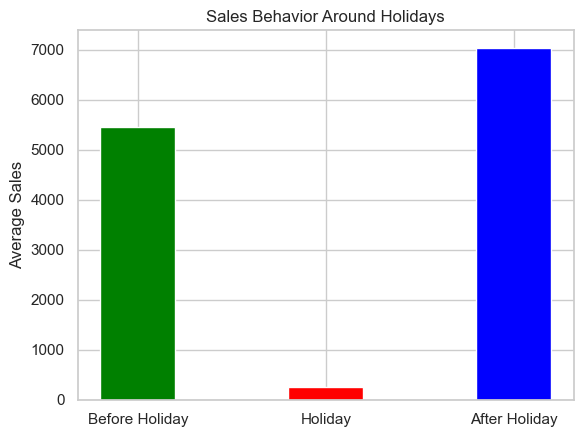

In [15]:
labels = ['Before Holiday', 'Holiday', 'After Holiday']
values = [before_sales, holiday_sales, after_sales]

plt.figure()

# Thin bars and custom colors
plt.bar(labels, values, width=0.4, 
        color=['green', 'red', 'blue'])

plt.title("Sales Behavior Around Holidays")
plt.ylabel("Average Sales")

plt.show()

### ***Average Sales by Holiday Type***

In [16]:
train['StateHoliday'].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [17]:
holiday_map = {
    '0': 'No Holiday',
    'a': 'Public Holiday',
    'b': 'Easter',
    'c': 'Christmas'
}

train['HolidayType'] = train['StateHoliday'].map(holiday_map)

In [18]:
holiday_sales = train.groupby('HolidayType')['Sales'].mean()
print(holiday_sales)

HolidayType
Christmas         168.73
Easter            214.31
No Holiday       5947.48
Public Holiday    290.74
Name: Sales, dtype: float64


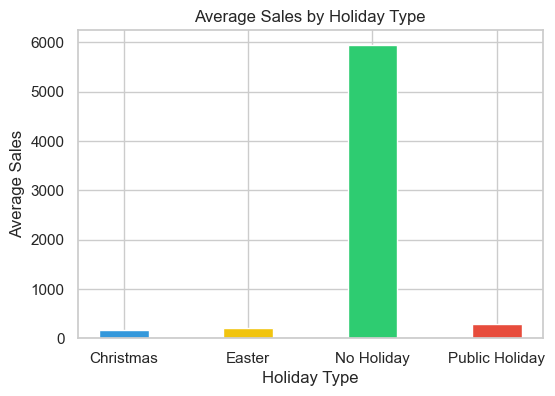

In [19]:
labels = holiday_sales.index
values = holiday_sales.values

plt.figure(figsize=(6,4))

plt.bar(labels, values, width=0.4,
        color=['#3498db', '#f1c40f', '#2ecc71', '#e74c3c'])

plt.title("Average Sales by Holiday Type")
plt.xlabel("Holiday Type")
plt.ylabel("Average Sales")

plt.show()

### ***Correlation between Sales and Customers***

           Sales  Customers
Sales       1.00       0.89
Customers   0.89       1.00


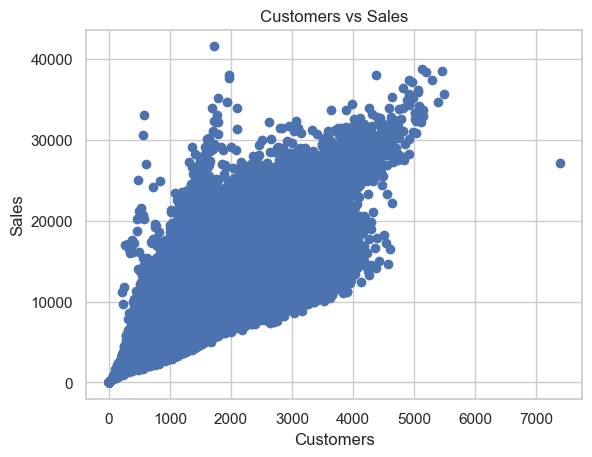

In [20]:
print(train[['Sales', 'Customers']].corr())

#visualization

plt.figure()

plt.scatter(train['Customers'], train['Sales'])
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.title("Customers vs Sales")

plt.show()

### ***Promo vs No Promo: Customers and Sales Comparison***

In [21]:
promo_map = {
    0: 'No Promo',
    1: 'Promo'
}

train['PromoLabel'] = train['Promo'].map(promo_map)

In [22]:
result = train.groupby('PromoLabel')[['Customers', 'Sales']].mean()
print(result)

            Customers   Sales
PromoLabel                   
No Promo       517.82 4406.05
Promo          820.10 7991.15


In [23]:
train['Sales_per_Customer'] = train['Sales'] / train['Customers']

train.groupby('Promo')['Sales_per_Customer'].mean()

Promo
0    8.94
1   10.18
Name: Sales_per_Customer, dtype: float64

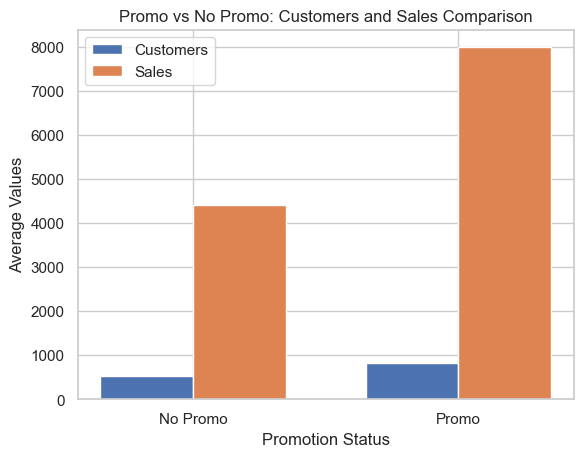

In [24]:
labels = result.index  # ['No Promo', 'Promo']

customers = result['Customers']
sales = result['Sales']

x = np.arange(len(labels))  # positions
width = 0.35

plt.figure()

# Bars
plt.bar(x - width/2, customers, width, label='Customers')
plt.bar(x + width/2, sales, width, label='Sales')

# Labels
plt.xticks(x, labels)
plt.xlabel("Promotion Status")
plt.ylabel("Average Values")
plt.title("Promo vs No Promo: Customers and Sales Comparison")

plt.legend()

plt.show()

In [25]:
promo_store = train.groupby(['Store', 'Promo'])['Sales'].mean().unstack()

promo_store.columns = ['No Promo', 'Promo']

promo_store['Increase'] = promo_store['Promo'] - promo_store['No Promo']

print(promo_store.head())

       No Promo    Promo  Increase
Store                             
1       3198.99  5152.89   1953.89
2       2855.06  6172.82   3317.76
3       3967.60  8608.67   4641.07
4       6568.94 10370.51   3801.57
5       2582.27  5944.27   3362.00


       No Promo    Promo  Increase
Store                             
817    14043.34 24679.57  10636.23
261     6694.37 16478.11   9783.74
544     8329.31 17072.36   8743.04
1014    6853.45 15334.43   8480.98
963     5758.71 13982.88   8224.18
788    11869.65 19927.80   8058.15
335    10306.77 18175.53   7868.75
251    12810.09 20670.54   7860.45
513    12155.92 19937.94   7782.01
831     7541.96 15264.75   7722.79


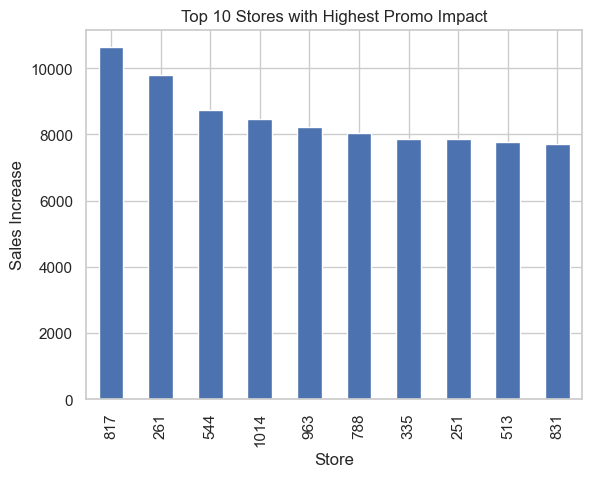

In [26]:
top_stores = promo_store.sort_values('Increase', ascending=False)

print(top_stores.head(10))

#visulation

top_stores['Increase'].head(10).plot(kind='bar')

plt.title("Top 10 Stores with Highest Promo Impact")
plt.ylabel("Sales Increase")

plt.show()

       No Promo    Promo  Increase
Store                             
274     4124.95  3870.26   -254.68
948     6759.48  6953.60    194.11
353     5483.20  5734.87    251.67
676     7387.36  7660.13    272.77
262    20549.64 20991.54    441.90
85      7100.61  7550.27    449.66
512     5211.20  5755.22    544.03
530     4169.91  4921.69    751.78
259    11175.52 12076.99    901.46
423    10453.68 11434.21    980.53


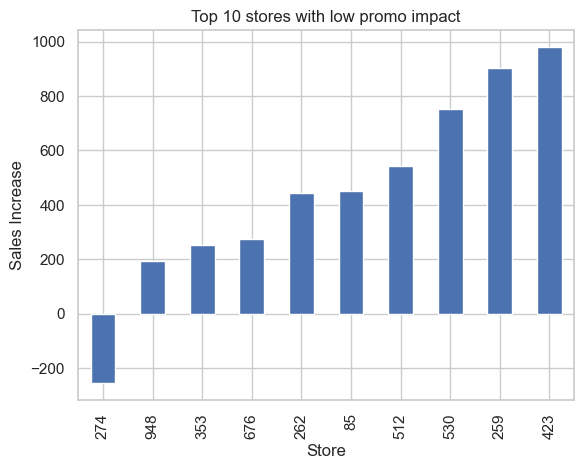

In [27]:
low_stores = promo_store.sort_values('Increase')

print(low_stores.head(10))

#visulation

low_stores ['Increase'].head(10).plot(kind='bar')

plt.title("Top 10 stores with low promo impact")
plt.ylabel("Sales Increase")

plt.show()

In [28]:
open = {
    0: 'Closed',
    1: 'Open'
}

train['StoreStatus'] = train['Open'].map(open)

status_analysis = train.groupby('StoreStatus')[['Customers', 'Sales']].mean()

print(status_analysis)

             Customers   Sales
StoreStatus                   
Closed            0.00    0.00
Open            762.73 6955.51


In [29]:
# Weekday data
weekday_data = train[train['DayOfWeek'].isin([1,2,3,4,5])]

# Stores always open on weekdays
weekday_open = weekday_data.groupby('Store')['Open'].min()

# Keep only stores open on all weekdays
always_open_stores = weekday_open[weekday_open == 1]

print("Stores open on all weekdays:")
print(always_open_stores.index.tolist())

print("\nTotal Stores:")
print(len(always_open_stores))

Stores open on all weekdays:
[85, 262, 335, 423, 494, 562, 682, 733, 769, 1097]

Total Stores:
10


In [30]:
# Weekend data for always-open stores
weekend_sales = train[
    (train['Store'].isin(always_open_stores)) &
    (train['DayOfWeek'].isin([6,7]))
]

# Average weekend sales
weekend_sales_analysis = weekend_sales.groupby('DayOfWeek')['Sales'].mean()

print(weekend_sales_analysis.round(2))

DayOfWeek
6   4942.97
7      0.00
Name: Sales, dtype: float64


In [31]:
# Weekend sales for those stores
weekend_sales = train[
    (train['Store'].isin(always_open_stores.index)) &
    (train['DayOfWeek'].isin([6,7]))
]

# Average weekend sales
weekend_sales_analysis = weekend_sales.groupby('Store')['Sales'].mean()

print(weekend_sales_analysis.round(2))

Store
85      8439.34
262    22994.38
335     8457.11
423    11059.32
494     6647.32
562    16441.30
682     7595.27
733    14579.51
769    10455.57
1097    9602.00
Name: Sales, dtype: float64


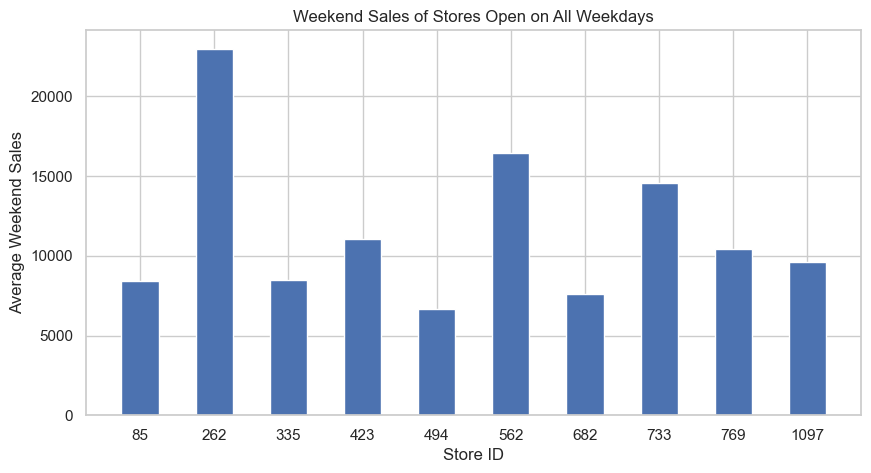

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(weekend_sales_analysis.index.astype(str),
        weekend_sales_analysis.values,
        width=0.5)

plt.title("Weekend Sales of Stores Open on All Weekdays")
plt.xlabel("Store ID")
plt.ylabel("Average Weekend Sales")

plt.show()

Weekend Sales Comparison:

Not Open All Weekdays    2945.49
Open All Weekdays       11627.11
Name: Sales, dtype: float64


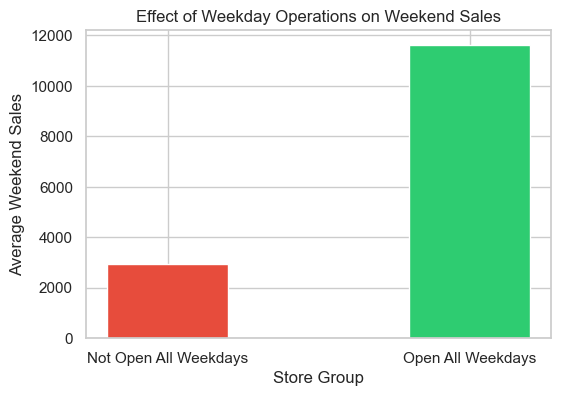

In [33]:
# --------------------------------------------
# Stores Open on All Weekdays & Their Weekend Sales
# --------------------------------------------

# Step 1: Filter weekday data (Monday-Friday)
weekday_data = train[train['DayOfWeek'].isin([1, 2, 3, 4, 5])]

# Step 2: Check which stores are always open on weekdays
# min() = if any day is closed (0), result becomes 0
weekday_open = weekday_data.groupby('Store')['Open'].min()

# Step 3: Keep only stores open on all weekdays
always_open_stores = weekday_open[weekday_open == 1].index

# Step 4: Filter weekend data (Saturday-Sunday)
weekend_data = train[train['DayOfWeek'].isin([6, 7])].copy()

# Step 5: Create two groups:
# True  = stores open on all weekdays
# False = other stores
weekend_data['StoreGroup'] = weekend_data['Store'].isin(always_open_stores)

# Step 6: Compare average weekend sales
weekend_sales_comparison = weekend_data.groupby('StoreGroup')['Sales'].mean()

# Step 7: Rename labels for readability
weekend_sales_comparison.index = [
    'Not Open All Weekdays',
    'Open All Weekdays'
]

# Step 8: Print result
print("Weekend Sales Comparison:\n")
print(weekend_sales_comparison.round(2))

# --------------------------------------------
# Visualization
# --------------------------------------------

plt.figure(figsize=(6,4))

plt.bar(
    weekend_sales_comparison.index,
    weekend_sales_comparison.values,
    width=0.4,
    color=['#e74c3c', '#2ecc71']
)

plt.title("Effect of Weekday Operations on Weekend Sales")
plt.xlabel("Store Group")
plt.ylabel("Average Weekend Sales")

plt.show()

In [34]:
store = pd.read_csv(r"C:\Users\saket\Downloads\rossmann-store-sales\store.csv"
)
train_store = pd.merge(train, store, on='Store', how='left')

assortment_map = {
    'a': 'Basic',
    'b': 'Extra',
    'c': 'Extended'
}

train_store['AssortmentType'] = train_store['Assortment'].map(assortment_map)

AssortmentType
Basic      5481.03
Extended   6058.68
Extra      8553.93
Name: Sales, dtype: float64


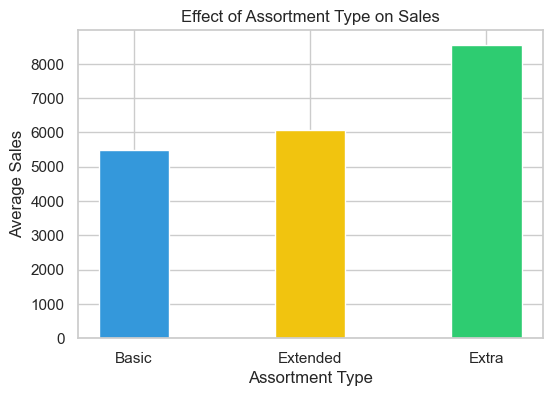

In [35]:
assortment_sales = train_store.groupby('AssortmentType')['Sales'].mean()

print(assortment_sales.round(2))

#vusualization 

plt.figure(figsize=(6,4))

plt.bar(
    assortment_sales.index,
    assortment_sales.values,
    width=0.4,
    color=['#3498db', '#f1c40f', '#2ecc71']
)

plt.title("Effect of Assortment Type on Sales")
plt.xlabel("Assortment Type")
plt.ylabel("Average Sales")

plt.show()

### ***Competition Distance vs Sales***

In [36]:
# Check average competitor distance
print(train_store['CompetitionDistance'].describe())

count   1014567.00
mean       5430.09
std        7715.32
min          20.00
25%         710.00
50%        2330.00
75%        6890.00
max       75860.00
Name: CompetitionDistance, dtype: float64


                     Sales  CompetitionDistance
Sales                 1.00                -0.02
CompetitionDistance  -0.02                 1.00


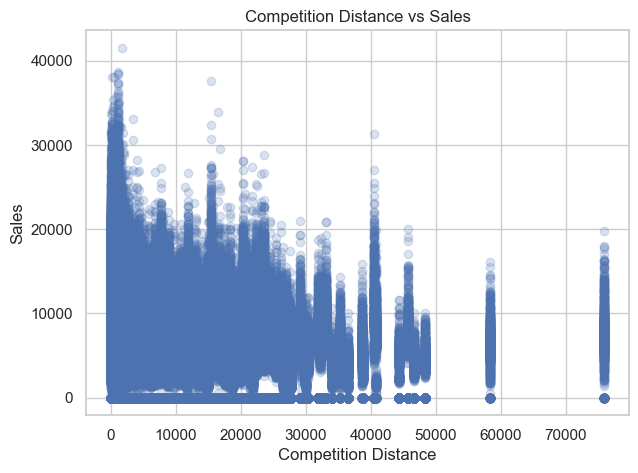

In [37]:
correlation = train_store[['Sales', 'CompetitionDistance']].corr()

print(correlation)

# Remove missing values
distance_data = train_store.dropna(subset=['CompetitionDistance'])

plt.figure(figsize=(7,5))

plt.scatter(
    distance_data['CompetitionDistance'],
    distance_data['Sales'],
    alpha=0.2
)

plt.xlabel("Competition Distance")
plt.ylabel("Sales")
plt.title("Competition Distance vs Sales")

plt.show()

In [38]:
# Create distance groups
train_store['DistanceGroup'] = pd.cut(
    train_store['CompetitionDistance'],
    bins=5
)

# Average sales by distance group
distance_sales = train_store.groupby('DistanceGroup')['Sales'].mean()

print(distance_sales.round(2))

DistanceGroup
(-55.84, 15188.0]    5773.26
(15188.0, 30356.0]   5859.22
(30356.0, 45524.0]   5531.21
(45524.0, 60692.0]   5131.03
(60692.0, 75860.0]   7321.47
Name: Sales, dtype: float64


C:\Users\saket\AppData\Local\Temp\ipykernel_14852\3143282308.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_sales = train_store.groupby('DistanceGroup')['Sales'].mean()


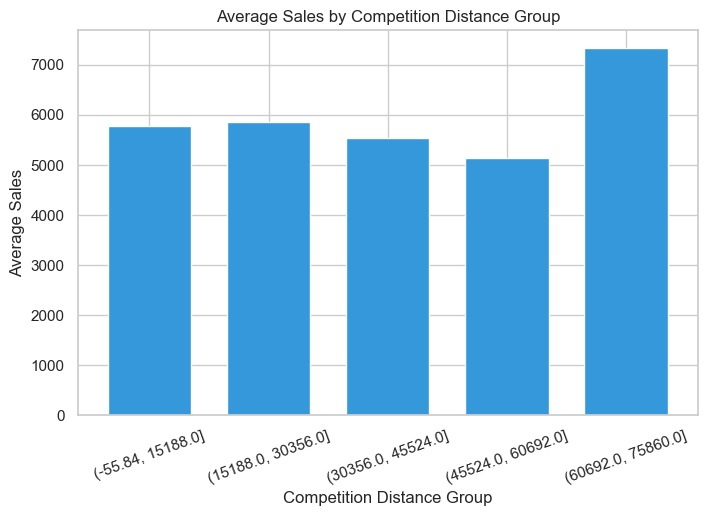

In [39]:
plt.figure(figsize=(8,5))

distance_sales.plot(
    kind='bar',
    color='#3498db',
    width=0.7
)

plt.title("Average Sales by Competition Distance Group")
plt.xlabel("Competition Distance Group")
plt.ylabel("Average Sales")

plt.xticks(rotation=20)

plt.show()

In [40]:
# Stores with missing competitor distance
na_competitor = train_store[
    train_store['CompetitionDistance'].isna()
]['Store'].unique()

print("Stores with NA Competition Distance:\n")
print(na_competitor)

Stores with NA Competition Distance:

[291 622 879]


In [41]:
# Stores that later got competition distance values
updated_competitor = train_store[
    (train_store['Store'].isin(na_competitor)) &
    (train_store['CompetitionDistance'].notna())
]

print(updated_competitor[['Store', 'CompetitionDistance']].head())

Empty DataFrame
Columns: [Store, CompetitionDistance]
Index: []


In [42]:
# Before competitor data
before_competitor = train_store[
    train_store['CompetitionDistance'].isna()
]

# After competitor data
after_competitor = train_store[
    train_store['CompetitionDistance'].notna()
]

# Average sales comparison
before_sales = before_competitor['Sales'].mean()
after_sales = after_competitor['Sales'].mean()

print("Average Sales Before Competitor:", round(before_sales,2))
print("Average Sales After Competitor :", round(after_sales,2))

Average Sales Before Competitor: 4535.89
Average Sales After Competitor : 5777.04


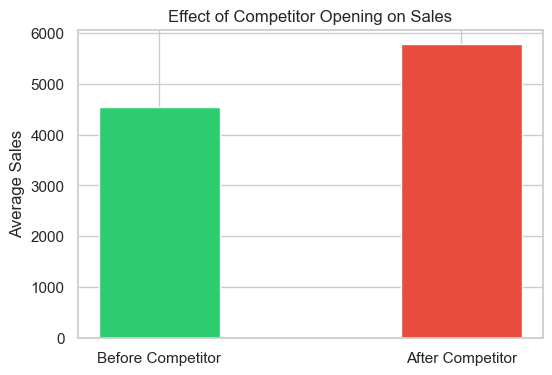

In [43]:
import matplotlib.pyplot as plt

labels = ['Before Competitor', 'After Competitor']
values = [before_sales, after_sales]

plt.figure(figsize=(6,4))

plt.bar(
    labels,
    values,
    width=0.4,
    color=['#2ecc71', '#e74c3c']
)

plt.title("Effect of Competitor Opening on Sales")
plt.ylabel("Average Sales")

plt.show()

## ***Logging***

In [44]:
# Logger configuration
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logger = logging.getLogger()

In [45]:
logger.info("Loading train dataset")

logger.info("Train dataset loaded successfully")

2026-05-08 13:36:24,462 - INFO - Loading train dataset
2026-05-08 13:36:24,463 - INFO - Train dataset loaded successfully


In [46]:
logger.info("Loading train dataset")

train = pd.read_csv(
    r"C:\Users\saket\Downloads\rossmann-store-sales\train.csv",
    low_memory=False
)

logger.info("Train dataset loaded successfully")

2026-05-08 13:36:24,473 - INFO - Loading train dataset
2026-05-08 13:36:25,327 - INFO - Train dataset loaded successfully


In [47]:
logger.info("Merging train and store datasets")

train_store = pd.merge(train, store, on='Store', how='left')

logger.info("Datasets merged successfully")

2026-05-08 13:36:25,337 - INFO - Merging train and store datasets
2026-05-08 13:36:25,598 - INFO - Datasets merged successfully


In [48]:
logger.info("Analyzing promo effect on sales")

2026-05-08 13:36:25,607 - INFO - Analyzing promo effect on sales


In [49]:
try:
    train_store['AssortmentType'] = train_store['Assortment'].map(assortment_map)
    logger.info("Assortment mapping completed")

except Exception as e:
    logger.error(f"Error occurred: {e}")

2026-05-08 13:36:25,690 - INFO - Assortment mapping completed


In [50]:
train_store = pd.merge(train, store, on='Store', how='left')
test_store = pd.merge(test, store, on='Store', how='left')

In [51]:
logger.info("Checking missing values")

print(train_store.isnull().sum())

2026-05-08 13:36:25,989 - INFO - Checking missing values


Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64


In [52]:
logger.info("Handling missing values")

train_store['CompetitionDistance'] = train_store[
    'CompetitionDistance'
].fillna(
    train_store['CompetitionDistance'].median()
)

test_store['CompetitionDistance'] = test_store[
    'CompetitionDistance'
].fillna(
    test_store['CompetitionDistance'].median()
)

2026-05-08 13:36:26,211 - INFO - Handling missing values


In [53]:
logger.info("Converting Date column")

train_store['Date'] = pd.to_datetime(train_store['Date'])
test_store['Date'] = pd.to_datetime(test_store['Date'])

2026-05-08 13:36:26,244 - INFO - Converting Date column


In [54]:
logger.info("Creating date features")

for df in [train_store, test_store]:

    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['Weekend'] = df['Date'].dt.dayofweek.isin([5,6]).astype(int)

2026-05-08 13:36:26,385 - INFO - Creating date features


In [55]:
logger.info("Encoding categorical variables")

encoder = LabelEncoder()

categorical_cols = [
    'StoreType',
    'Assortment',
    'StateHoliday'
]

for col in categorical_cols:

    train_store[col] = encoder.fit_transform(
        train_store[col].astype(str)
    )

    test_store[col] = encoder.transform(
        test_store[col].astype(str)
    )

2026-05-08 13:36:26,700 - INFO - Encoding categorical variables


In [56]:
logger.info("Removing closed stores")

train_store = train_store[
    train_store['Open'] == 1
]

2026-05-08 13:36:27,297 - INFO - Removing closed stores


In [57]:
logger.info("Selecting features")

features = [
    'Store',
    'DayOfWeek',
    'Promo',
    'SchoolHoliday',
    'CompetitionDistance',
    'StoreType',
    'Assortment',
    'Year',
    'Month',
    'Day',
    'WeekOfYear',
    'Weekend'
]

X = train_store[features]

y = train_store['Sales']

2026-05-08 13:36:27,508 - INFO - Selecting features


In [58]:
logger.info("Splitting dataset")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

2026-05-08 13:36:27,643 - INFO - Splitting dataset


In [59]:
logger.info("Training Random Forest model")

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

logger.info("Model training completed")

2026-05-08 13:36:27,952 - INFO - Training Random Forest model
2026-05-08 13:45:28,581 - INFO - Model training completed


In [60]:
logger.info("Generating predictions")

y_pred = model.predict(X_test)

2026-05-08 13:45:28,693 - INFO - Generating predictions


In [61]:
logger.info("Evaluating model")

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,2))

2026-05-08 13:45:43,324 - INFO - Evaluating model


MAE : 621.67
RMSE: 987.49
R2 Score: 0.9


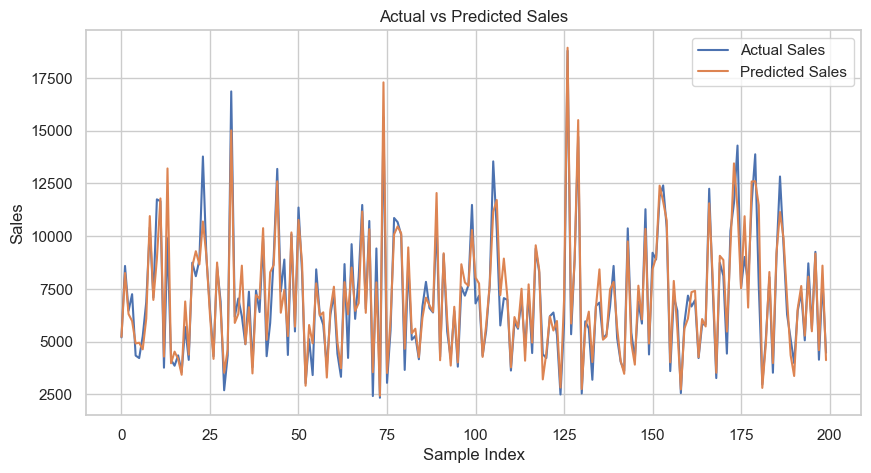

In [62]:
# Select first 200 samples for better visualization

actual_values = y_test[:200]

predicted_values = y_pred[:200]

# Create figure
plt.figure(figsize=(10,5))

# Plot actual sales
plt.plot(
    actual_values.values,
    label='Actual Sales'
)

# Plot predicted sales
plt.plot(
    predicted_values,
    label='Predicted Sales'
)

# Labels and title
plt.title("Actual vs Predicted Sales")

plt.xlabel("Sample Index")

plt.ylabel("Sales")

# Show legend
plt.legend()

# Display chart
plt.show()

In [63]:
importance = pd.DataFrame({

    'Feature': features,
    'Importance': model.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                Feature  Importance
0                 Store        0.32
4   CompetitionDistance        0.28
2                 Promo        0.14
1             DayOfWeek        0.06
5             StoreType        0.05
9                   Day        0.05
10           WeekOfYear        0.04
6            Assortment        0.02
8                 Month        0.02
7                  Year        0.01
3         SchoolHoliday        0.01
11              Weekend        0.01


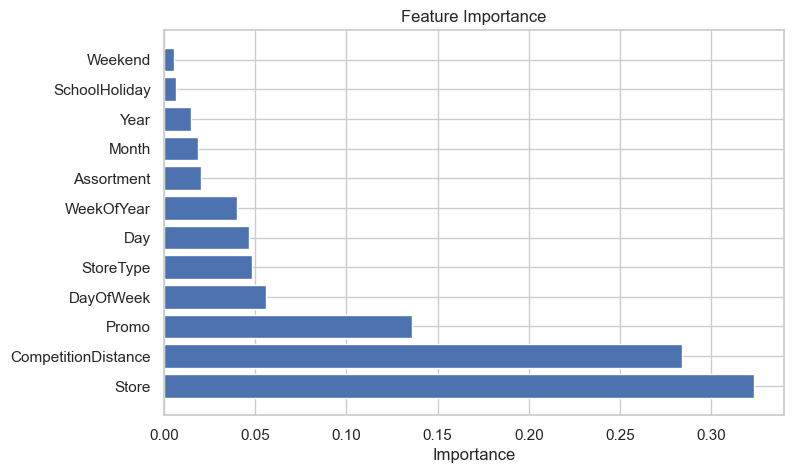

In [64]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.show()

In [65]:
future_X = test_store[features]

future_predictions = model.predict(future_X)

test_store['PredictedSales'] = future_predictions

In [66]:
print(test_store[
    ['Store', 'Date', 'PredictedSales']
].head())

   Store       Date  PredictedSales
0      1 2015-09-17         4439.03
1      3 2015-09-17         7620.88
2      7 2015-09-17         9193.39
3      8 2015-09-17         8307.96
4      9 2015-09-17         7704.46


In [67]:
submission = test_store[
    ['Id', 'PredictedSales']
]

submission.to_csv(
    'sales_predictions.csv',
    index=False
)

print("Prediction file saved")

Prediction file saved


In [68]:
# Convert Date column into datetime format

train_store['Date'] = pd.to_datetime(train_store['Date'])

test_store['Date'] = pd.to_datetime(test_store['Date'])

In [69]:
# Create basic date-related features

for df in [train_store, test_store]:

    # Extract year
    df['Year'] = df['Date'].dt.year

    # Extract month
    df['Month'] = df['Date'].dt.month

    # Extract day
    df['Day'] = df['Date'].dt.day

    # Extract week number
    df['WeekOfYear'] = (
        df['Date'].dt.isocalendar().week.astype(int)
    )

    # Extract day name
    df['Weekday'] = df['Date'].dt.day_name()

In [70]:
# Create weekend feature
# Saturday = 5, Sunday = 6

for df in [train_store, test_store]:

    df['IsWeekend'] = (
        df['Date'].dt.dayofweek.isin([5, 6])
    ).astype(int)

In [71]:
# Create month position features

for df in [train_store, test_store]:

    # Beginning of month
    df['IsMonthStart'] = (
        df['Day'] <= 10
    ).astype(int)

    # Mid month
    df['IsMidMonth'] = (
        (df['Day'] > 10) &
        (df['Day'] <= 20)
    ).astype(int)

    # End of month
    df['IsMonthEnd'] = (
        df['Day'] > 20
    ).astype(int)

In [72]:
# Create holiday indicator feature

for df in [train_store, test_store]:

    # Mark rows with holidays
    df['IsHoliday'] = (
        df['StateHoliday'] != '0'
    ).astype(int)

In [73]:
# Calculate days before holiday

for df in [train_store, test_store]:

    # Shift holiday column backward
    df['DaysToHoliday'] = (
        df['IsHoliday']
        .shift(-1)
        .fillna(0)
    )

In [74]:
# Calculate days after holiday

for df in [train_store, test_store]:

    # Shift holiday column forward
    df['DaysAfterHoliday'] = (
        df['IsHoliday']
        .shift(1)
        .fillna(0)
    )

In [75]:
# Extract quarter from date

for df in [train_store, test_store]:

    df['Quarter'] = (
        df['Date'].dt.quarter
    )

In [76]:
# Extract month name

for df in [train_store, test_store]:

    df['MonthName'] = (
        df['Date'].dt.month_name()
    )

In [77]:
# Create combined weekend and promo feature

for df in [train_store, test_store]:

    df['WeekendPromo'] = (
        (df['IsWeekend'] == 1) &
        (df['Promo'] == 1)
    ).astype(int)

In [78]:
# Encode categorical variables into numeric format

encoder = LabelEncoder()

categorical_cols = [
    'StoreType',
    'Assortment',
    'StateHoliday',
    'Weekday',
    'MonthName'
]

for col in categorical_cols:

    train_store[col] = encoder.fit_transform(
        train_store[col].astype(str)
    )

    test_store[col] = encoder.transform(
        test_store[col].astype(str)
    )

In [79]:
# Display processed dataset

print(train_store.head(10))

   Store  DayOfWeek       Date  Sales  Customers  Open  Promo  StateHoliday  \
0      1          5 2015-07-31   5263        555     1      1             0   
1      2          5 2015-07-31   6064        625     1      1             0   
2      3          5 2015-07-31   8314        821     1      1             0   
3      4          5 2015-07-31  13995       1498     1      1             0   
4      5          5 2015-07-31   4822        559     1      1             0   
5      6          5 2015-07-31   5651        589     1      1             0   
6      7          5 2015-07-31  15344       1414     1      1             0   
7      8          5 2015-07-31   8492        833     1      1             0   
8      9          5 2015-07-31   8565        687     1      1             0   
9     10          5 2015-07-31   7185        681     1      1             0   

   SchoolHoliday  StoreType  ...  IsWeekend  IsMonthStart  IsMidMonth  \
0              1          2  ...          0             0

In [80]:
# Create scaler object

scaler = StandardScaler()

# Scale training features

X_train_scaled = scaler.fit_transform(X_train)

# Scale testing features

X_test_scaled = scaler.transform(X_test)

# Scale future prediction data

future_X_scaled = scaler.transform(
    test_store[features]
)

# Check scaled data shape

print(
    "Scaled Training Data Shape:",
    X_train_scaled.shape
)

print(
    "Scaled Testing Data Shape:",
    X_test_scaled.shape
)

Scaled Training Data Shape: (675513, 12)
Scaled Testing Data Shape: (168879, 12)


In [81]:
# Create sklearn pipeline

pipeline = Pipeline([

    (
        'model',

        RandomForestRegressor(
            n_estimators=50,
            random_state=42
        )
    )

])

# Train pipeline

pipeline.fit(
    X_train_scaled,
    y_train
)

# Predict testing data

pipeline_pred = pipeline.predict(
    X_test_scaled
)

In [82]:
# Evaluate pipeline model

pipeline_mae = mean_absolute_error(
    y_test,
    pipeline_pred
)

pipeline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pipeline_pred
    )
)

pipeline_r2 = r2_score(
    y_test,
    pipeline_pred
)

# Display results

print(
    "Pipeline MAE:",
    round(pipeline_mae, 2)
)

print(
    "Pipeline RMSE:",
    round(pipeline_rmse, 2)
)

print(
    "Pipeline R2 Score:",
    round(pipeline_r2, 2)
)

Pipeline MAE: 624.56
Pipeline RMSE: 990.94
Pipeline R2 Score: 0.9


In [83]:
# Extract feature importance

pipeline_importance = pd.DataFrame({

    'Feature': features,

    'Importance': pipeline.named_steps[
        'model'
    ].feature_importances_

})

# Sort values

pipeline_importance = (
    pipeline_importance.sort_values(
        by='Importance',
        ascending=False
    )
)

# Display feature importance

print(pipeline_importance)

                Feature  Importance
0                 Store        0.32
4   CompetitionDistance        0.28
2                 Promo        0.14
1             DayOfWeek        0.06
5             StoreType        0.05
9                   Day        0.05
10           WeekOfYear        0.04
6            Assortment        0.02
8                 Month        0.02
7                  Year        0.01
3         SchoolHoliday        0.01
11              Weekend        0.01


In [84]:
# Predict future sales

pipeline_future_predictions = (
    pipeline.predict(
        future_X_scaled
    )
)

# Store predictions

test_store[
    'PipelinePredictedSales'
] = pipeline_future_predictions

In [85]:
# Chosen Loss Function:
# Mean Absolute Error (MAE)

# Reason:
# MAE is easy to interpret because it directly
# measures the average prediction error in sales units.

# It is suitable for business problems like
# sales forecasting where understanding the
# average error is important.

# MAE is also less sensitive to outliers
# compared to MSE and RMSE.

In [86]:
# Calculate MAE

mae = mean_absolute_error(
    y_test,
    y_pred
)

# Calculate RMSE

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

# Calculate R2 score

r2 = r2_score(
    y_test,
    y_pred
)

# Display results

print(
    "Mean Absolute Error:",
    round(mae, 2)
)

print(
    "Root Mean Squared Error:",
    round(rmse, 2)
)

print(
    "R2 Score:",
    round(r2, 2)
)

Mean Absolute Error: 621.67
Root Mean Squared Error: 987.49
R2 Score: 0.9


In [87]:
# ====================================
# Task 2.4 - Feature Importance Analysis
# ====================================

# Extract feature importance from pipeline model

importance = pd.DataFrame({

    'Feature': features,

    'Importance': pipeline.named_steps[
        'model'
    ].feature_importances_

})

# Sort importance values

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# Display feature importance

print(importance)

                Feature  Importance
0                 Store        0.32
4   CompetitionDistance        0.28
2                 Promo        0.14
1             DayOfWeek        0.06
5             StoreType        0.05
9                   Day        0.05
10           WeekOfYear        0.04
6            Assortment        0.02
8                 Month        0.02
7                  Year        0.01
3         SchoolHoliday        0.01
11              Weekend        0.01


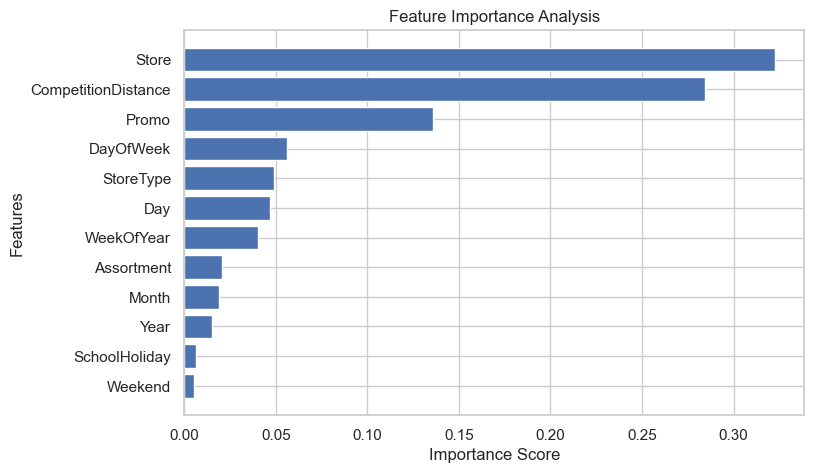

In [88]:
# Plot feature importance

plt.figure(figsize=(8,5))

plt.barh(

    importance['Feature'],

    importance['Importance']

)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Feature Importance Analysis")

plt.gca().invert_yaxis()

plt.show()

In [89]:
# Insight:
# Features with higher importance scores
# contribute more to sales prediction.

# Promo, Store, CompetitionDistance,
# and seasonal date features are expected
# to strongly influence sales.

In [90]:
# ====================================
# Confidence Interval Estimation
# ====================================

# Calculate prediction errors

errors = y_test - y_pred

# Calculate standard deviation of errors

error_std = np.std(errors)

# Lower confidence limit

lower_bound = y_pred - error_std

# Upper confidence limit

upper_bound = y_pred + error_std

In [91]:
# Create confidence interval dataframe

confidence_df = pd.DataFrame({

    'Actual Sales': y_test.values,

    'Predicted Sales': y_pred,

    'Lower Bound': lower_bound,

    'Upper Bound': upper_bound

})

# Display sample predictions

print(confidence_df.head(10))

   Actual Sales  Predicted Sales  Lower Bound  Upper Bound
0          5203          5231.04      4243.55      6218.53
1          8590          8253.88      7266.39      9241.37
2          6465          6307.12      5319.63      7294.61
3          7250          5976.65      4989.16      6964.14
4          4339          4913.42      3925.93      5900.91
5          4221          4948.37      3960.88      5935.86
6          5258          4634.61      3647.12      5622.10
7          6882          6094.70      5107.21      7082.19
8         10413         10954.78      9967.29     11942.27
9          7090          6978.63      5991.14      7966.12


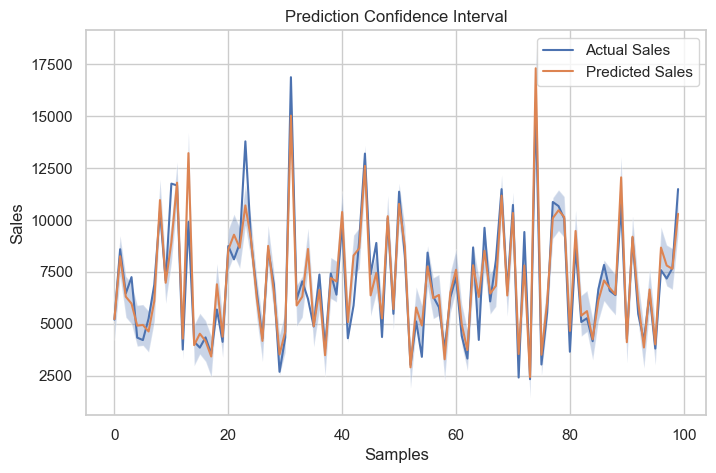

In [92]:
# Plot confidence interval

plt.figure(figsize=(8,5))

# Actual sales

plt.plot(

    y_test.values[:100],

    label='Actual Sales'
)

# Predicted sales

plt.plot(

    y_pred[:100],

    label='Predicted Sales'
)

# Confidence interval

plt.fill_between(

    range(100),

    lower_bound[:100],

    upper_bound[:100],

    alpha=0.3

)

plt.title("Prediction Confidence Interval")

plt.xlabel("Samples")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [93]:
# Generate timestamp

timestamp = datetime.now().strftime(
    "%d-%m-%Y-%H-%M-%S"
)

# Create model filename

model_filename = (
    f"{timestamp}.pkl"
)

# Save trained pipeline model

joblib.dump(
    pipeline,
    model_filename
)

print(
    f"Model saved as: {model_filename}"
)

Model saved as: 08-05-2026-13-50-12.pkl


In [94]:
# Sort dataset by date

train_store = train_store.sort_values(
    by='Date'
)

# Select important columns

time_series_data = train_store[[
    
    'Date',
    'Sales',
    'Customers',
    'Promo',
    'CompetitionDistance'

]]

# Display dataset

print(
    time_series_data.head()
)

              Date  Sales  Customers  Promo  CompetitionDistance
1017190 2013-01-01   5961       1405      0               720.00
1016179 2013-01-01   4220        619      0              1870.00
1016353 2013-01-01   6851       1444      0               210.00
1016356 2013-01-01  17267       2875      0              1180.00
1016368 2013-01-01   3102        729      0              3640.00


In [95]:
# ====================================
# Stationarity Check with Sampling
# ====================================

# Take smaller sample from sales series

sales_series = (
    time_series_data['Sales']
    .dropna()
    .sample(50000, random_state=42)
)

# Apply ADF test

adf_result = adfuller(
    sales_series
)

# Print ADF Statistic

print(
    "ADF Statistic:",
    adf_result[0]
)

# Print p-value

print(
    "p-value:",
    adf_result[1]
)

# Print critical values

print("Critical Values:")

for key, value in adf_result[4].items():

    print(
        key,
        ":",
        value
    )

ADF Statistic: -224.25688326102375
p-value: 0.0
Critical Values:
1% : -3.4304807953310763
5% : -2.8615978088501315
10% : -2.566800769739017


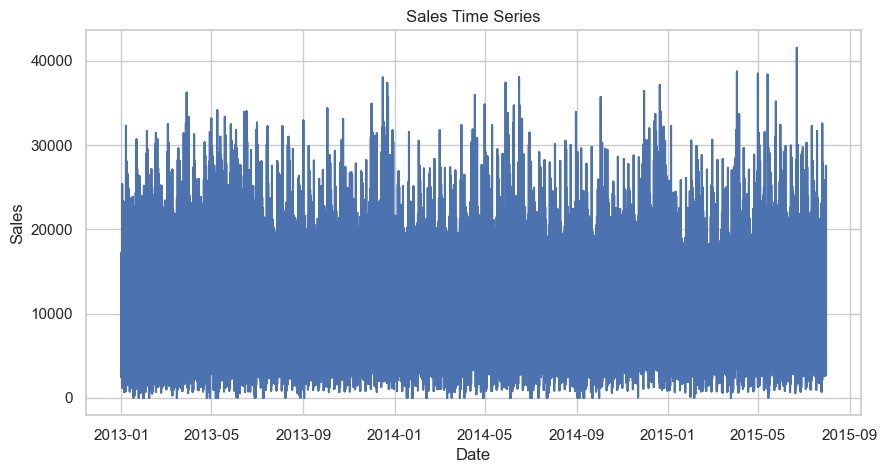

In [96]:
# Plot sales time series

plt.figure(figsize=(10,5))

plt.plot(
    time_series_data['Date'],
    time_series_data['Sales']
)

plt.title(
    "Sales Time Series"
)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [97]:
# ====================================
# Step 3 - Differencing Time Series
# ====================================

# Create differenced sales series

time_series_data[
    'DifferencedSales'
] = (
    time_series_data[
        'Sales'
    ].diff()
)

# Remove missing values

time_series_data = (
    time_series_data.dropna()
)

# Display dataset

print(
    time_series_data.head()
)

              Date  Sales  Customers  Promo  CompetitionDistance  \
1016179 2013-01-01   4220        619      0              1870.00   
1016353 2013-01-01   6851       1444      0               210.00   
1016356 2013-01-01  17267       2875      0              1180.00   
1016368 2013-01-01   3102        729      0              3640.00   
1016429 2013-01-01   2401        482      0                90.00   

         DifferencedSales  
1016179          -1741.00  
1016353           2631.00  
1016356          10416.00  
1016368         -14165.00  
1016429           -701.00  


C:\Users\saket\AppData\Local\Temp\ipykernel_14852\4196882255.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_series_data[


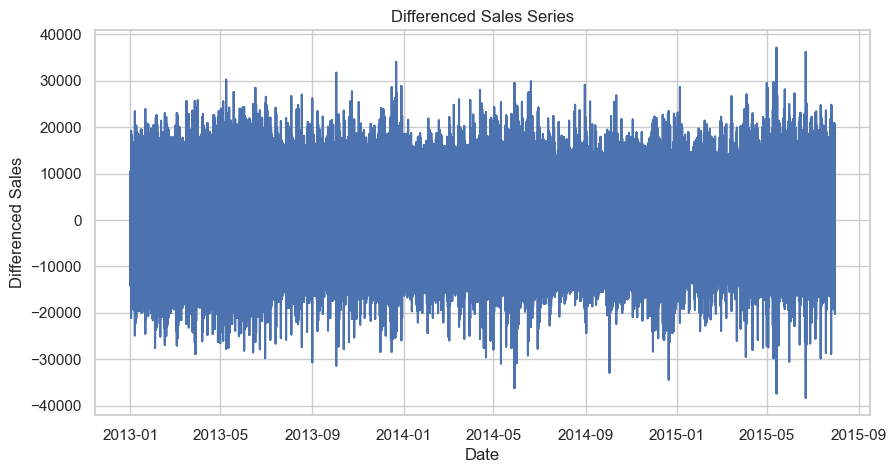

In [98]:
# Plot differenced sales

plt.figure(figsize=(10,5))

plt.plot(

    time_series_data['Date'],

    time_series_data[
        'DifferencedSales'
    ]

)

plt.title(
    "Differenced Sales Series"
)

plt.xlabel("Date")

plt.ylabel("Differenced Sales")

plt.show()

<Figure size 1000x500 with 0 Axes>

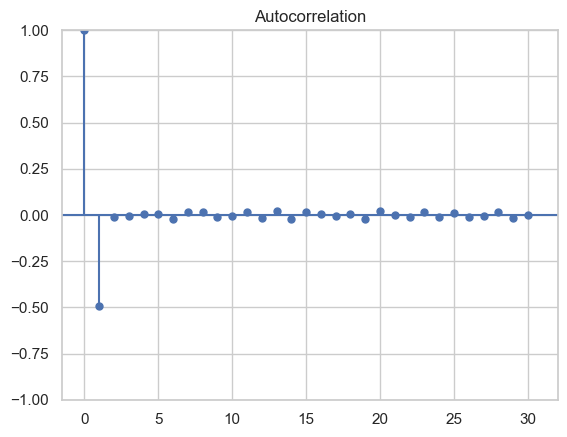

In [99]:
# Import libraries

from statsmodels.graphics.tsaplots import (

    plot_acf,
    plot_pacf

)

# Plot autocorrelation

plt.figure(figsize=(10,5))

plot_acf(

    time_series_data[
        'DifferencedSales'
    ],

    lags=30

)

plt.show()

<Figure size 1000x500 with 0 Axes>

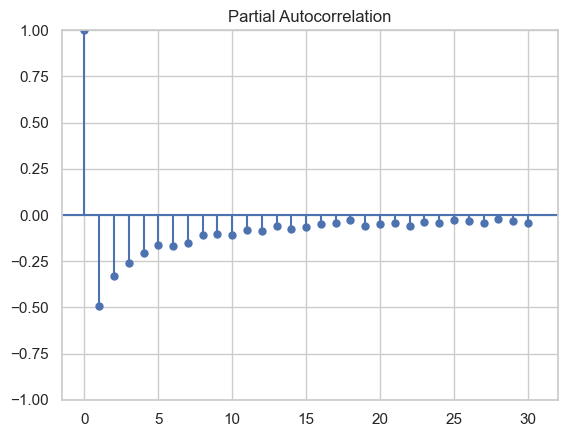

In [100]:
# Plot partial autocorrelation

plt.figure(figsize=(10,5))

plot_pacf(

    time_series_data[
        'DifferencedSales'
    ],

    lags=30

)

plt.show()

In [101]:
# ====================================
# Step 5 - Supervised Learning Data
# ====================================

# Create sliding window function

def create_dataset(
    
    dataset,
    look_back=1

):

    X = []
    y = []

    for i in range(
        len(dataset) - look_back
    ):

        X.append(
            dataset[
                i:(i + look_back)
            ]
        )

        y.append(
            dataset[
                i + look_back
            ]
        )

    return (
        np.array(X),
        np.array(y)
    )

In [102]:
# Extract sales values

sales_values = time_series_data[
    'DifferencedSales'
].values

In [103]:
# ====================================
# Step 6 - Scaling Data
# ====================================

# Import scaler

from sklearn.preprocessing import MinMaxScaler

# Create scaler

scaler = MinMaxScaler(
    feature_range=(-1, 1)
)

# Reshape data

sales_values = sales_values.reshape(
    -1,
    1
)

# Scale data

scaled_sales = scaler.fit_transform(
    sales_values
)

# Display scaled values

print(
    scaled_sales[:5]
)

[[-0.03045665]
 [ 0.08558385]
 [ 0.29221133]
 [-0.36021127]
 [-0.00285324]]


In [104]:
# Create supervised learning dataset

look_back = 10

X, y = create_dataset(

    scaled_sales,

    look_back

)

In [105]:
# Reshape input for LSTM

X = X.reshape(

    X.shape[0],

    X.shape[1],

    1

)

print(X.shape)

print(y.shape)

(844381, 10, 1)
(844381, 1)


In [106]:
# Split dataset

train_size = int(
    len(X) * 0.8
)

X_train = X[:train_size]

X_test = X[train_size:]

y_train = y[:train_size]

y_test = y[train_size:]

In [107]:
# Import deep learning libraries

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    LSTM,
    Dense

)

In [108]:
# ====================================
# Step 7 - LSTM Model
# ====================================

# Create LSTM model

model = Sequential()



# Add first LSTM layer

model.add(

    LSTM(

        50,

        return_sequences=True,

        input_shape=(
            look_back,
            1
        )

    )

)

C:\Users\saket\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [109]:
# Add second LSTM layer

model.add(

    LSTM(50)

)

In [110]:
# Add output layer

model.add(

    Dense(1)

)

In [111]:
# Compile model

model.compile(

    optimizer='adam',

    loss='mean_squared_error'

)

In [112]:
# Train LSTM model

history = model.fit(

    X_train,

    y_train,

    epochs=10,

    batch_size=32,

    validation_data=(

        X_test,
        y_test

    )

)

Epoch 1/10
21110/21110 ━━━━━━━━━━━━━━━━━━━━ 182s 8ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 2/10
21110/21110 ━━━━━━━━━━━━━━━━━━━━ 186s 8ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 3/10
21110/21110 ━━━━━━━━━━━━━━━━━━━━ 164s 8ms/step - loss: 0.0054 - val_loss: 0.0054
Epoch 4/10
21110/21110 ━━━━━━━━━━━━━━━━━━━━ 163s 8ms/step - loss: 0.0054 - val_loss: 0.0054
Epoch 5/10
21110/21110 ━━━━━━━━━━━━━━━━━━━━ 186s 9ms/step - loss: 0.0053 - val_loss: 0.0053
Epoch 6/10
21110/21110 ━━━━━━━━━━━━━━━━━━━━ 196s 9ms/step - loss: 0.0052 - val_loss: 0.0052
Epoch 7/10
21110/21110 ━━━━━━━━━━━━━━━━━━━━ 190s 8ms/step - loss: 0.0051 - val_loss: 0.0050
Epoch 8/10
21110/21110 ━━━━━━━━━━━━━━━━━━━━ 195s 8ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 9/10
21110/21110 ━━━━━━━━━━━━━━━━━━━━ 192s 9ms/step - loss: 0.0048 - val_loss: 0.0048
Epoch 10/10
21110/21110 ━━━━━━━━━━━━━━━━━━━━ 179s 8ms/step - loss: 0.0046 - val_loss: 0.0047


In [113]:
# Predict sales

predictions = model.predict(
    X_test
)

5278/5278 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step


In [114]:
# Convert predictions back

predictions = scaler.inverse_transform(
    predictions
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

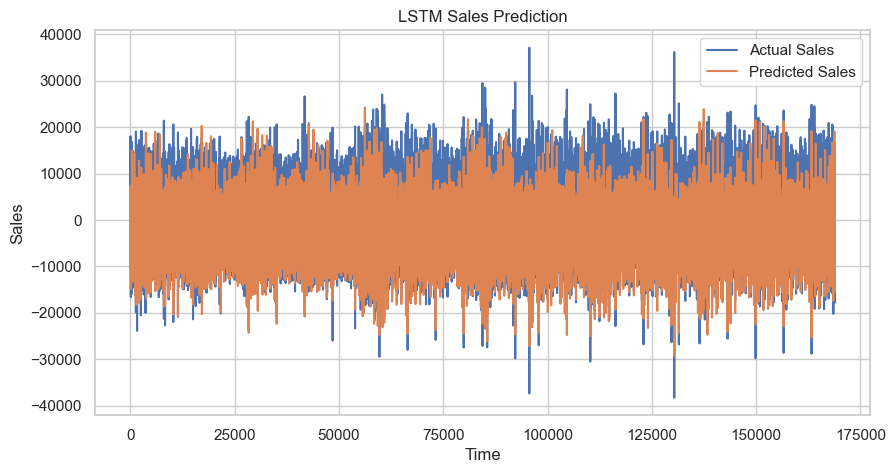

In [115]:
# Plot actual vs predicted sales

plt.figure(figsize=(10,5))

plt.plot(

    y_test_actual,

    label='Actual Sales'

)

plt.plot(

    predictions,

    label='Predicted Sales'

)

plt.title(
    "LSTM Sales Prediction"
)

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [116]:
# Start MLflow run

with mlflow.start_run():

    # Log model parameters

    mlflow.log_param(
        "n_estimators",
        100
    )

    mlflow.log_param(
        "random_state",
        42
    )

    # Log evaluation metrics

    mlflow.log_metric(
        "MAE",
        mae
    )

    mlflow.log_metric(
        "R2_Score",
        r2
    )

    # Save trained model

    mlflow.sklearn.log_model(

        model,

        "random_forest_model"

    )

2026/05/08 14:27:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 14:27:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [117]:
# Make predictions on test data

test_predictions = model.predict(
    X_test
)

# Display predictions

print(
    test_predictions[:10]
)

5278/5278 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step
[[ 0.04216115]
 [ 0.08167862]
 [-0.04811288]
 [ 0.14121196]
 [ 0.0113709 ]
 [-0.16675945]
 [ 0.06737286]
 [ 0.01987597]
 [-0.00469233]
 [-0.00104514]]
